# 02 EDA and Statistical Analysis

This notebook is part of the end-to-end bank loan propensity prediction and MLOps deployment project.

## Import Libraries

In [1]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

import math

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", "{:.2f}".format)

## Loading Data

In [2]:
# Load Cleaned Customer Dataset

# Define data directory
INTERIM_DIR = Path("../data/processed")

# Load cleaned customer dataset
cust_data = pd.read_csv(
    INTERIM_DIR / "02_cleaned_customer_data.csv"
)

cust_data.head()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,10,34,9,180,93023,1,8.90,3,0,0,0,0,0,1
1,11,65,39,105,94710,4,2.40,3,0,0,0,0,0,0
2,12,29,5,45,90277,3,0.10,2,0,0,0,1,0,0
3,13,48,23,114,93106,2,3.80,3,0,1,0,0,0,0
4,14,59,32,40,94920,4,2.50,2,0,0,0,1,0,0


## Recreate Feature Groups

In [3]:
# ==========================================================
# Feature Classification
# ==========================================================

target_col = "LoanOnCard"

id_cols = ["ID"]

location_cols = ["ZipCode"]

num_cols = [
    "Age",
    "CustomerSince",
    "HighestSpend",
    "MonthlyAverageSpend",
    "Mortgage"
]

ordinal_cols = [
    "Level",
    "HiddenScore"
]

binary_cols = [
    "Security",
    "FixedDepositAccount",
    "InternetBanking",
    "CreditCard"
]

# Univariate Analysis

### Target Variable Analysis

In [4]:
# Target Variable Distribution

target_summary = pd.DataFrame({
    "Count": cust_data[target_col].value_counts(),
    "Percentage (%)": (
        cust_data[target_col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

target_summary

,Count,Percentage (%)
LoanOnCard,,
0,4500,90.36
1,480,9.64


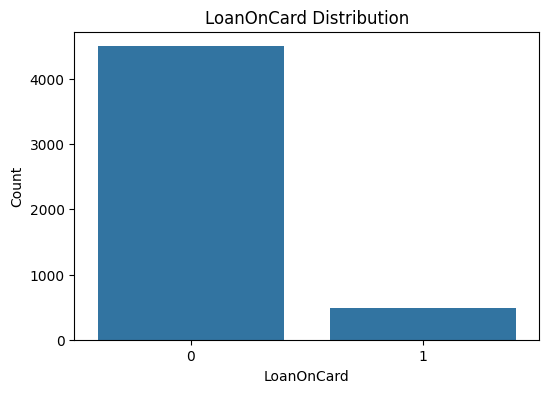

In [5]:
# Target Variable Distribution Plot

plt.figure(figsize=(6, 4))

sns.countplot(
    data=cust_data,
    x=target_col
)

plt.title("LoanOnCard Distribution")
plt.xlabel("LoanOnCard")
plt.ylabel("Count")

plt.show()

## Interpretation

The target variable exhibits a significant class imbalance.

### Majority Class

Customers without a loan on their credit card:

Class = 0
Count = 4,500
Percentage = 90.36%

### Minority Class

Customers with a loan on their credit card:

Class = 1
Count = 480
Percentage = 9.64%

## Business Insight

Only approximately 1 out of every 10 customers has a loan on their credit card.

This indicates that loan adoption is relatively uncommon within the customer base.

From a marketing perspective, this reflects the business challenge described in the project statement:

- Most customers are liability customers rather than asset customers, making borrower identification a relatively rare event.

## Modeling Implications

The target variable is highly imbalanced, with the minority class representing only 9.64% of all observations.

As a result:
- Accuracy alone will not be a reliable evaluation metric.
- Recall, Precision, F1-Score, and ROC-AUC will be emphasized.
- Class imbalance mitigation techniques such as SMOTE and hybrid resampling will be evaluated during model development.

### Numerical Variable Analysis

### Descriptive Statistics for Numerical Variables

In [6]:
# Summary Statistics

cust_data[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,4980.00,45.35,11.46,23.00,35.00,45.00,55.00,67.00
CustomerSince,4980.00,20.12,11.47,-3.00,10.00,20.00,30.00,43.00
HighestSpend,4980.00,73.85,46.07,8.00,39.00,64.00,98.00,224.00
MonthlyAverageSpend,4980.00,1.94,1.75,0.00,0.70,1.50,2.52,10.00
Mortgage,4980.00,56.59,101.84,0.00,0.00,0.00,101.00,635.00


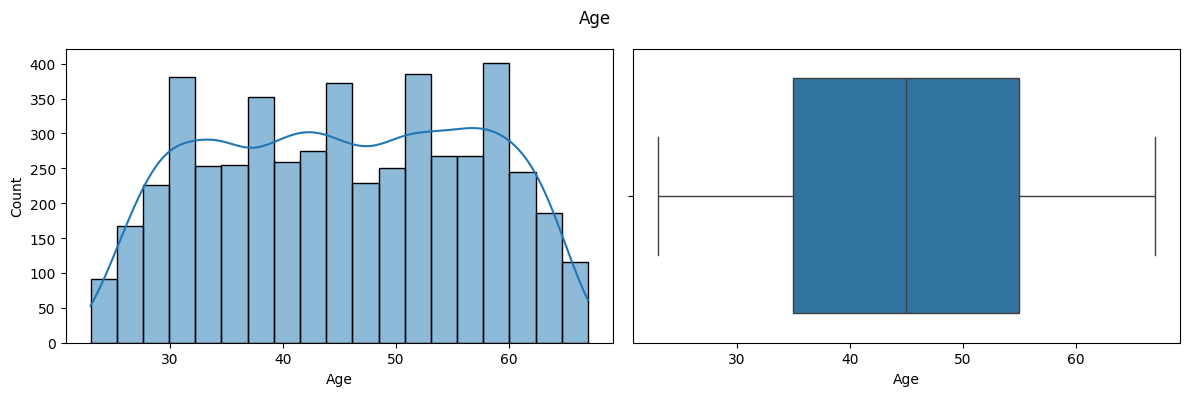

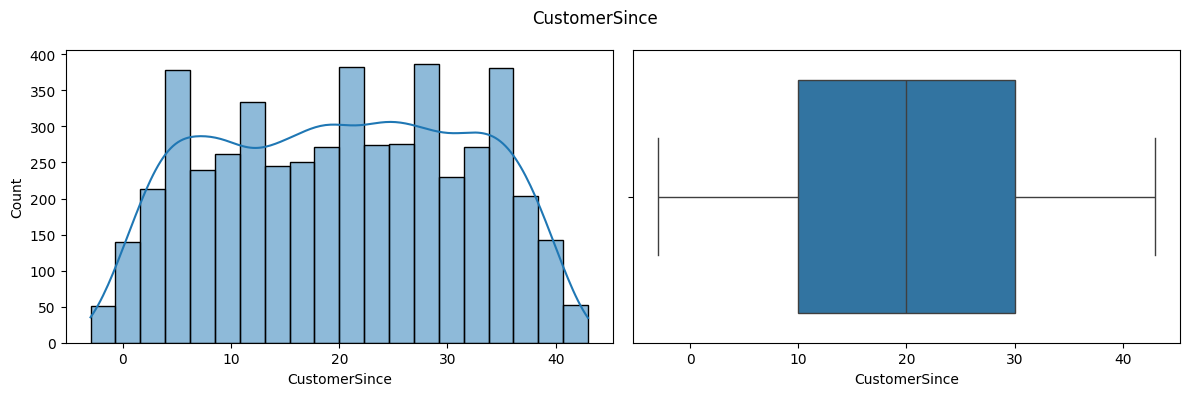

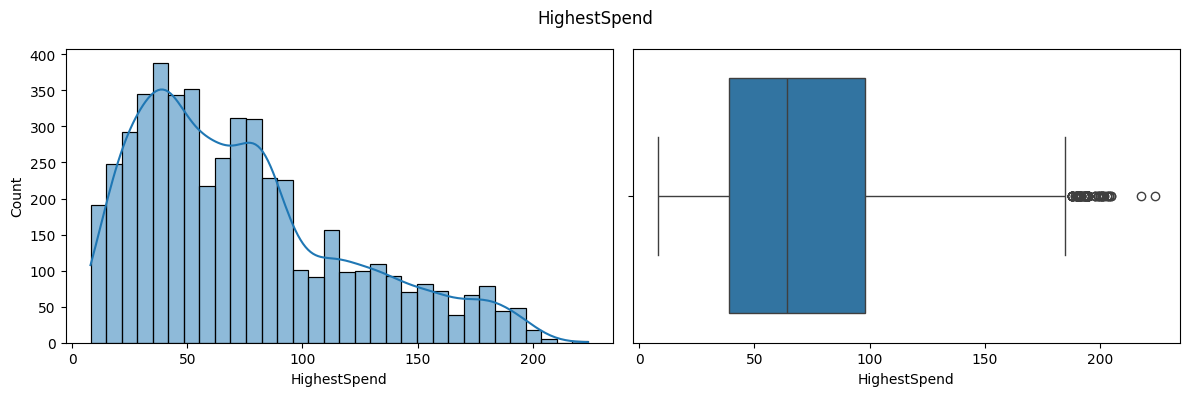

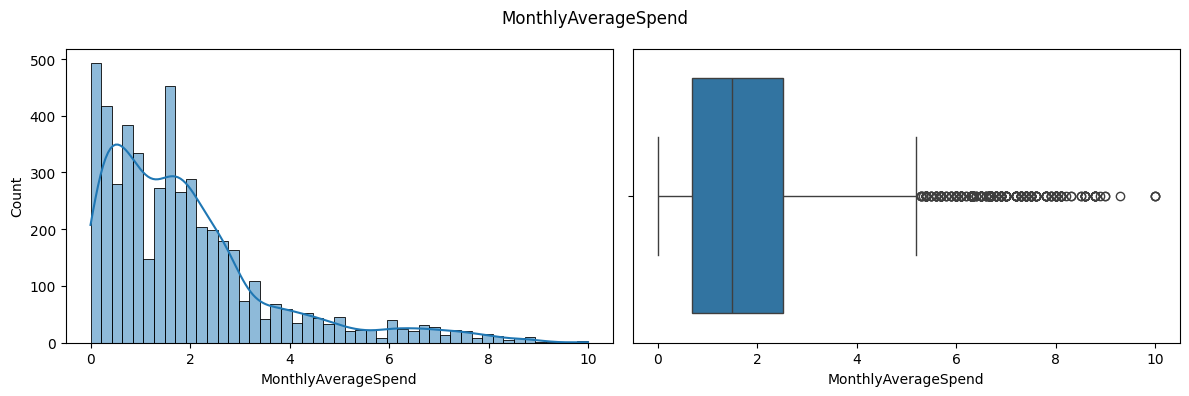

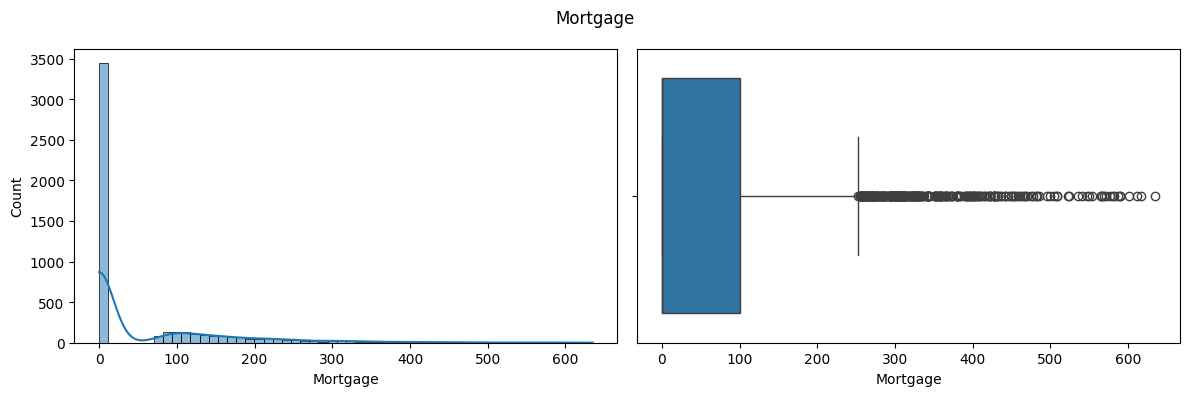

In [7]:
# Distribution Analysis
for col in num_cols:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,4)
    )

    sns.histplot(
        cust_data[col],
        kde=True,
        ax=axes[0]
    )

    sns.boxplot(
        x=cust_data[col],
        ax=axes[1]
    )

    plt.suptitle(col)

    plt.tight_layout()

    plt.show()

## Explanation

### Age
#### Observations
- Age ranges from approximately 23 to 67 years.
- The histogram shows a relatively uniform distribution across age groups.
- The median age is approximately 45 years.
- The boxplot does not indicate the presence of significant outliers.

#### Interpretation

The customer base consists primarily of middle-aged individuals, with a balanced representation across age categories.

#### Conclusion
- Approximately symmetric distribution
- No significant outliers
- No transformation required

---

### CustomerSince
#### Observations
- Values range from -3 to 43.
- The distribution appears relatively uniform.
- A small number of negative values are present.
- No extreme observations are visible in the boxplot.

#### Interpretation

The negative values previously identified do not appear anomalous when viewed within the overall distribution.

#### Conclusion
- Relatively symmetric distribution
- No significant outliers
- Negative values retained

---

### HighestSpend
#### Observations
- Distribution is positively skewed.
- Majority of customers have highest transaction amounts below 100.
- A small number of customers exhibit exceptionally high spending behavior.
- Multiple upper-end outliers are visible in the boxplot.

#### Interpretation

The presence of high-value transactions suggests that a subset of customers demonstrates substantially greater purchasing power than the average customer.

#### Conclusion
- Moderately right-skewed distribution
- Outliers present
- Further outlier analysis required

### MonthlyAverageSpend
#### Observations
- Strong positive skew is evident.
- Most customers spend relatively small amounts on average.
- A long right tail extends toward higher spending levels.
- Numerous upper-end outliers are visible.

#### Interpretation

The customer population contains a small segment of high-spending customers that significantly influence the overall distribution.

#### Conclusion
- Highly right-skewed distribution
- Significant outliers present
- Candidate for transformation analysis

---

### Mortgage
#### Observations
- A substantial proportion of customers have mortgage values equal to zero.
- The distribution exhibits extreme positive skewness.
- A long tail extends toward very high mortgage balances.
- Large numbers of outliers are visible.

#### Interpretation

Most customers do not have mortgage obligations, while a relatively small segment carries substantial mortgage balances.

This pattern is common in banking datasets and reflects naturally occurring customer behavior rather than data quality issues.

#### Conclusion
- Extremely right-skewed distribution
- Significant zero inflation
- Numerous outliers present
- Strong candidate for feature engineering

## Distribution Shape Analysis

In [8]:
cust_data[num_cols].agg([
    "mean",
    "median",
    "std",
    "skew",
    "kurt"
]).round(2).T

,mean,median,std,skew,kurt
Age,45.35,45.00,11.46,-0.03,-1.15
CustomerSince,20.12,20.00,11.47,-0.03,-1.12
HighestSpend,73.85,64.00,46.07,0.84,-0.05
MonthlyAverageSpend,1.94,1.50,1.75,1.60,2.63
Mortgage,56.59,0.00,101.84,2.10,4.74


## Observation

### Age
- The average customer age is 45.35 years, with a median age of 45 years, indicating that the distribution is centered around middle-aged customers.
- The mean and median are nearly identical, suggesting a highly symmetric distribution.
- The skewness value (-0.03) is very close to zero, confirming the absence of meaningful skewness.
- The negative kurtosis (-1.15) indicates a flatter distribution than a normal distribution, suggesting ages are relatively evenly spread across the observed range.

### Inference: 
Age appears well distributed across customers and does not exhibit significant distributional irregularities.

---

### CustomerSince
- Customers have been associated with the bank for an average of 20.13 years, with a median tenure of 20 years.
- The similarity between the mean and median suggests a symmetric distribution.
- Skewness (-0.02) is negligible, indicating virtually no asymmetry.
- The negative kurtosis (-1.14) suggests a relatively flat distribution with observations spread across tenure levels.

### Inference: 
The dataset contains a balanced mix of both newer and long-standing customers.

---

### HighestSpend
- The average highest spend is 73.85, while the median is 64, indicating that higher spending values pull the mean upward.
- The positive skewness (0.84) suggests a moderate right-skewed distribution.
- The standard deviation (46.07) indicates considerable variability in spending behavior.
- Kurtosis (-0.05) is close to zero, suggesting tail behavior similar to a normal distribution.

### Inference: 
Spending behavior varies substantially across customers, with a subset of customers exhibiting notably higher spending levels.

---

### MonthlyAverageSpend
- The average monthly spend is 1.94, compared with a median of 1.50.
- The large difference between mean and median indicates the presence of higher spending customers influencing the average.
- The skewness value (1.60) indicates strong positive skewness.
- Kurtosis (2.63) suggests a relatively heavy-tailed distribution compared with a normal distribution.

### Inference: 
Most customers exhibit relatively low monthly spending, while a smaller segment contributes disproportionately higher spending amounts.

---

### Mortgage
- The average mortgage value is 56.59, while the median is 0, indicating that more than half of customers have no mortgage balance.
- The large standard deviation (101.84) reflects substantial variability in mortgage amounts.
- The skewness value (2.10) indicates strong positive skewness.
- The kurtosis value (4.74) indicates a highly peaked distribution with heavy tails.

### Inference: 
Mortgage balances are concentrated among a subset of customers, while a large proportion have no mortgage obligations. This feature exhibits the strongest departure from normality among all numerical variables.

### Decision:

Log transformations will not be applied globally in Phase 4.

The original financial variables will be retained, and log-transformed alternatives will be evaluated during Phase 5 for models that may benefit from them, such as Logistic Regression and SVM.

## Outlier Analysis

In [9]:
# Detect outliers using the IQR method

outlier_summary = []

for col in num_cols:

    q1 = cust_data[col].quantile(0.25)
    q3 = cust_data[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = (
        ((cust_data[col] < lower) |
         (cust_data[col] > upper))
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": round(
            outlier_count / len(cust_data) * 100,
            2
        )
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df.sort_values(
    by="Outlier Percentage (%)",
    ascending=False
).reset_index(drop=True)

,Feature,Outlier Count,Outlier Percentage (%)
0,MonthlyAverageSpend,324,6.51
1,Mortgage,291,5.84
2,HighestSpend,96,1.93
3,Age,0,0.00
4,CustomerSince,0,0.00


## Business Insight

The majority of detected outliers occur within spending and mortgage-related variables.

This suggests that:

Extreme observations are primarily driven by customer financial behavior rather than data quality issues.

Such observations may contain valuable predictive information regarding loan adoption and should not be removed without further investigation.

## Ordinal Feature Analysis

In [10]:
# Frequency Tables
for col in ordinal_cols:

    freq_table = pd.DataFrame({
        "Count": cust_data[col].value_counts().sort_index(),
        "Percentage (%)": (
            cust_data[col]
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    })

    display(freq_table)

,Count,Percentage (%)
Level,,
1,2089,41.95
2,1395,28.01
3,1496,30.04


,Count,Percentage (%)
HiddenScore,,
1,1466,29.44
2,1293,25.96
3,1006,20.20
4,1215,24.40


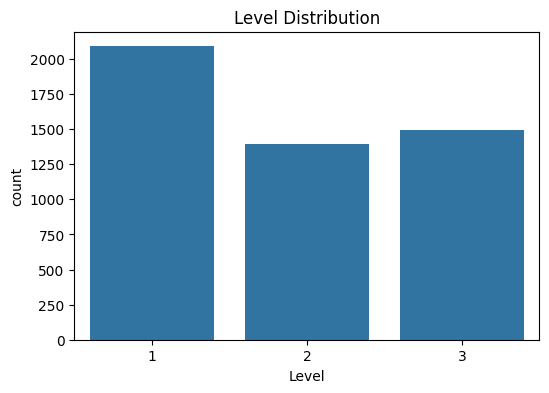

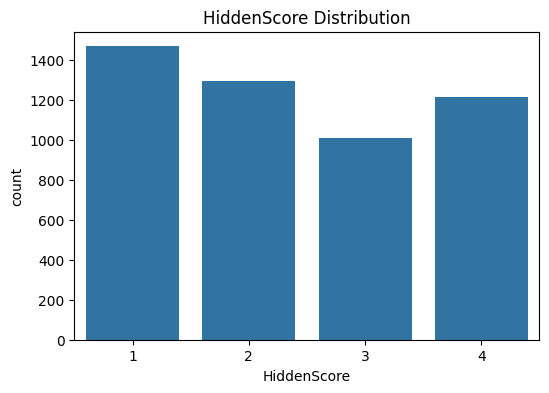

In [11]:
for col in ordinal_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=cust_data,
        x=col
    )

    plt.title(
        f"{col} Distribution"
    )

    plt.show()

## Binary Feature Analysis

In [12]:
# Frequency Tables
binary_summary = pd.DataFrame({
    "Count of 1s": cust_data[binary_cols].sum(),
    "Percentage of 1s (%)": cust_data[binary_cols].mean()*100
})

binary_summary.round(2)

,Count of 1s,Percentage of 1s (%)
Security,520,10.44
FixedDepositAccount,302,6.06
InternetBanking,2974,59.72
CreditCard,1466,29.44


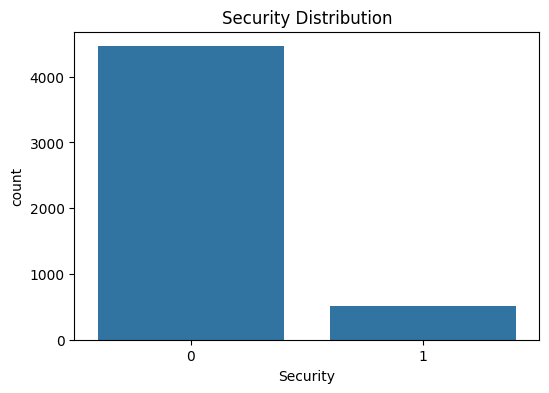

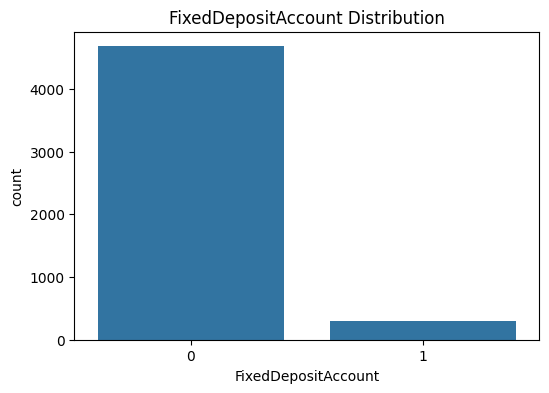

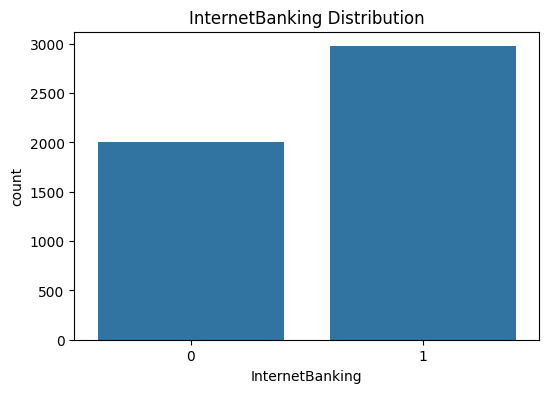

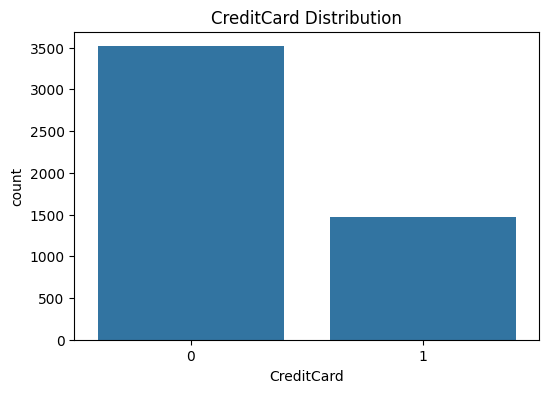

In [13]:
for col in binary_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=cust_data,
        x=col
    )

    plt.title(
        f"{col} Distribution"
    )

    plt.show()

## Bi-Variate Analysis

### Numerical vs Target

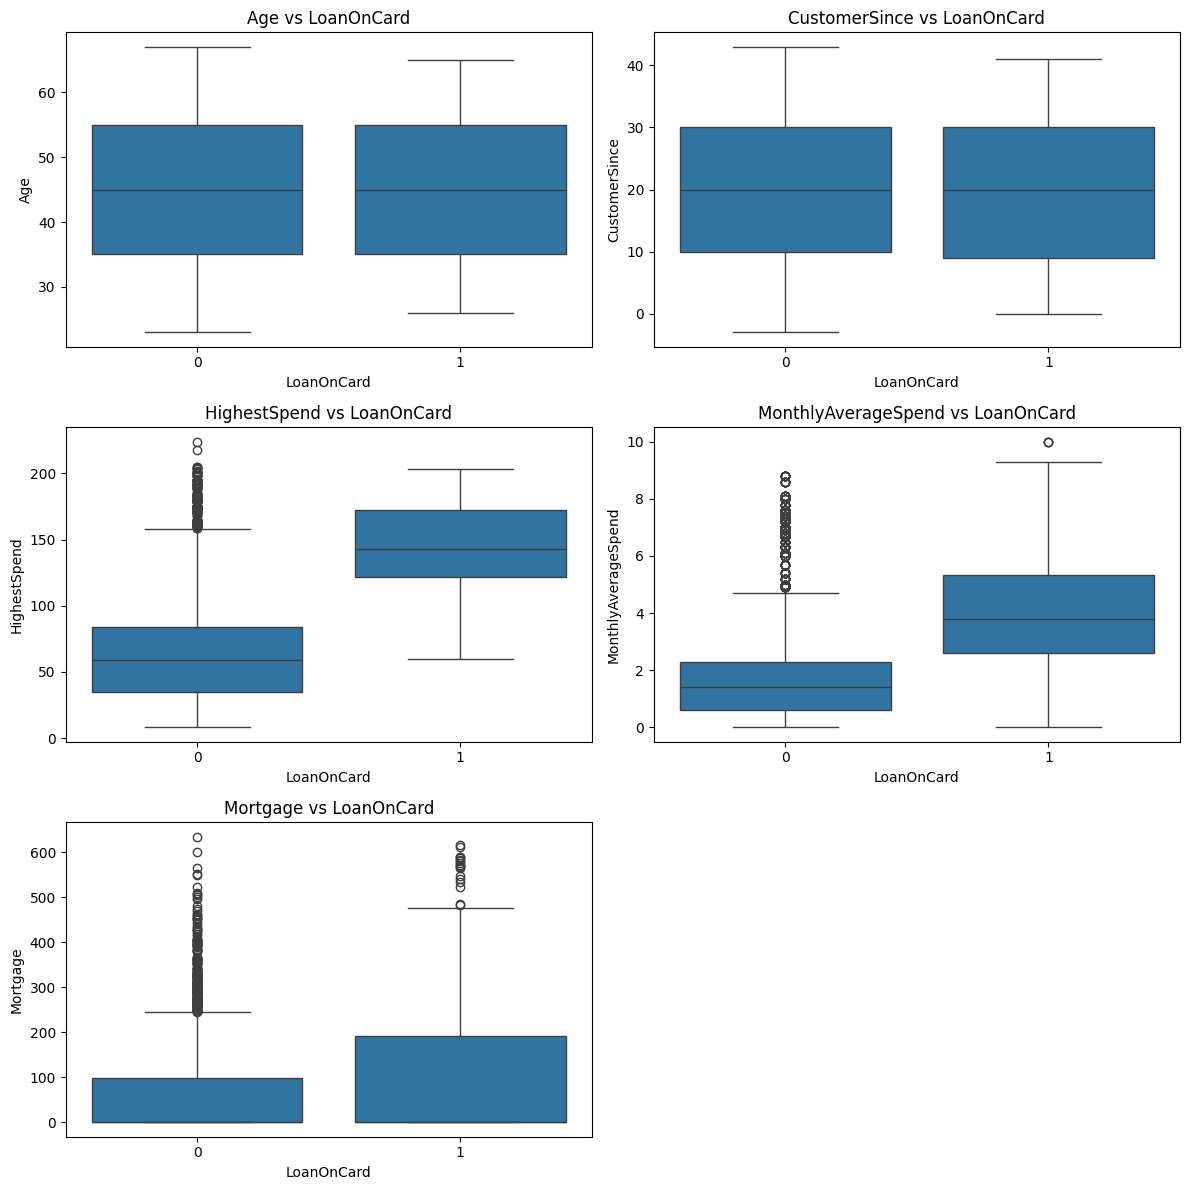

In [14]:
# Boxplots

n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.boxplot(
        data=cust_data,
        x=target_col,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs {target_col}")
    axes[i].set_xlabel(target_col)
    axes[i].set_ylabel(col)

# Remove unused subplot(s)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Observations

### Age vs LoanOnCard
#### Observations
- Both groups exhibit nearly identical distributions.
- Median age is approximately 45 years for both classes.
- Interquartile ranges overlap substantially.
- No meaningful separation is visible.

#### Interpretation
- Customer age appears to have limited influence on loan ownership.
- Customers with loans and customers without loans belong to very similar age groups.

#### Conclusion

Weak relationship with loan conversion.

---

### CustomerSince vs LoanOnCard
#### Observations
- Median customer tenure is approximately 20 for both classes.
- Distribution shapes are highly similar.
- Significant overlap exists between groups.

#### Interpretation

Length of relationship with the bank does not appear to strongly differentiate borrowers from non-borrowers.

#### Conclusion

Weak relationship with loan conversion.

---

### HighestSpend vs LoanOnCard
#### Observations
- Borrowers exhibit substantially higher transaction amounts.
- Median spending for loan holders is dramatically higher than for non-loan customers.
- The entire distribution for Class 1 is shifted upward.

#### Interpretation

Customers with larger historical transactions appear much more likely to have a loan.

This suggests that spending capacity may be strongly associated with borrowing behavior.

#### Conclusion
- Strong positive relationship with loan conversion.
- Potentially high predictive importance.

---

### MonthlyAverageSpend vs LoanOnCard
#### Observations
- Loan holders exhibit noticeably higher monthly spending.
- Median monthly spend is significantly greater for Class 1.
- Distributions show clear separation.

#### Interpretation

Customers with greater monthly spending activity are more likely to possess loan products.

This variable appears to capture customer purchasing power and financial engagement.

#### Conclusion
- Strong positive relationship with loan conversion.
- Potentially one of the most predictive features.

---

### Mortgage vs LoanOnCard
#### Observations
- Loan holders generally exhibit higher mortgage balances.
- Median mortgage values are noticeably larger among borrowers.
- Greater variability is observed within the loan group.

#### Interpretation

Customers already carrying larger financial obligations may be more inclined to utilize additional credit products.

Mortgage appears to differentiate borrowers from non-borrowers reasonably well.

#### Conclusion

Moderate-to-strong relationship with loan conversion.

In [15]:
# Mean Feature Values by Loan Status

cust_data.groupby(
    target_col
)[num_cols].agg(
    ["mean", "median"]
).round(2)

Age        CustomerSince        HighestSpend        MonthlyAverageSpend        Mortgage       
            mean median          mean median         mean median                mean median     mean median
LoanOnCard                                                                                                 
0          45.38  45.00         20.15  20.00        66.29  59.00                1.73   1.40    51.87   0.00
1          45.07  45.00         19.84  20.00       144.75 142.50                3.91   3.80   100.85   0.00

## Explanation

### Age
#### Observations
| Metric | Non-Borrowers | Borrowers |
|---------|--------------|-----------|
| Mean | 45.38 | 45.07 |
| Median | 45.00 | 45.00 |

#### Interpretation

The age distributions of borrowers and non-borrowers are virtually identical.

#### Conclusion

Age does not appear to be a meaningful differentiator of loan ownership.

---

### CustomerSince
#### Observations
| Metric | Non-Borrowers | Borrowers |
|---------|--------------|-----------|
| Mean | 20.15 | 19.84 |
| Median | 20.00 | 20.00 |

#### Interpretation

Customer tenure exhibits almost no variation between the two groups.

#### Conclusion

Customer tenure appears to have minimal predictive influence.

---

### HighestSpend
#### Observations
| Metric | Non-Borrowers | Borrowers |
|---------|--------------|-----------|
| Mean | 66.29 | 144.75 |
| Median | 59.00 | 142.50 |

#### Interpretation

Borrowers exhibit transaction amounts that are more than twice as large as those of non-borrowers.

The large difference in both mean and median values indicates a strong and consistent relationship.

#### Conclusion

Very strong predictor candidate.

---

### MonthlyAverageSpend
#### Observations
| Metric | Non-Borrowers | Borrowers |
|---------|--------------|-----------|
| Mean | 1.73 | 3.91 |
| Median | 1.40 | 3.80 |

#### Interpretation

Customers with loans spend substantially more on a monthly basis than customers without loans.

The difference is consistent across both mean and median measures.

#### Conclusion

One of the strongest predictor candidates.

---

### Mortgage
#### Observations
| Metric | Non-Borrowers | Borrowers |
|---------|--------------|-----------|
| Mean | 51.87 | 100.85 |
| Median | 0.00 | 0.00 |

#### Interpretation

Although the median mortgage value remains zero for both groups, the mean mortgage balance among borrowers is nearly twice that of non-borrowers.

This suggests that customers with larger mortgage obligations are more likely to hold loan products.

#### Conclusion

Moderate-to-strong predictor candidate.

---

### Business Insight

The analysis indicates that:

Financial behavior variables are far more informative than demographic variables when distinguishing borrowers from non-borrowers.

Customers who:
- Spend more per month
- Make larger transactions
- Carry larger mortgage balances

are significantly more likely to possess loan products.

#### In contrast:

- Age
- Length of customer relationship

show little evidence of influencing loan adoption.

### Preliminary Feature Importance Assessment

| Predictor Strength | Features |
|--------------------|----------|
| Strong | MonthlyAverageSpend, HighestSpend |
| Moderate | Mortgage |
| Weak | Age, CustomerSince |

### Ordinal Variables vs Target

In [16]:
results = []

for col in ordinal_cols:

    if col == "LoanOnCard":
        continue

    rates = (
    cust_data
    .groupby(col, observed=True)["LoanOnCard"]
    .mean()
    .mul(100)
    .round(2)
)

    for category, rate in rates.items():

        results.append({
            "Variable": col,
            "Category": category,
            "Loan Adoption Rate (%)": rate
        })

categorical_summary = pd.DataFrame(results)

categorical_summary

,Variable,Category,Loan Adoption Rate (%)
0,Level,1,4.45
1,Level,2,13.05
2,Level,3,13.70
3,HiddenScore,1,7.30
4,HiddenScore,2,8.20
5,HiddenScore,3,13.22
6,HiddenScore,4,11.03


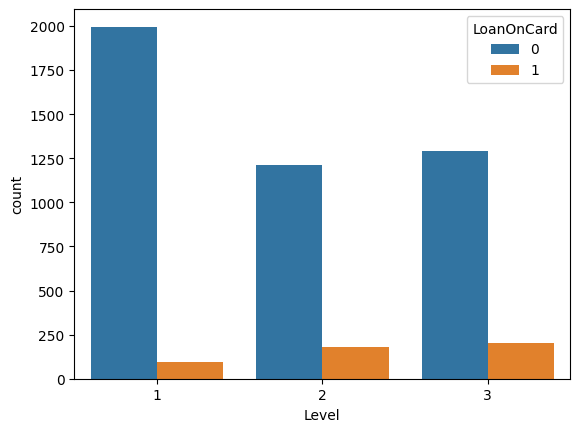

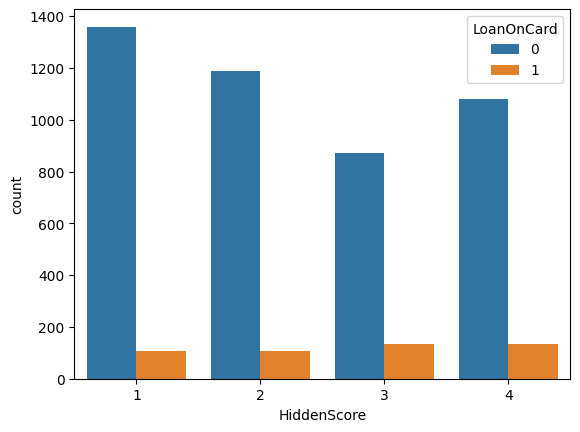

In [17]:
for col in ordinal_cols:

    sns.countplot(
        data=cust_data,
        x=col,
        hue=target_col
    )

    plt.show()

### Binary Variables vs Target

In [18]:
# Loan Conversion Rate by Ordinal Features

results = []

for col in binary_cols:

    counts = pd.crosstab(
        cust_data[col],
        cust_data[target_col]
    )

    percentages = (
        pd.crosstab(
            cust_data[col],
            cust_data[target_col],
            normalize="index"
        ) * 100
    ).round(2)

    adoption_rates = (
        cust_data
        .groupby(col, observed=True)[target_col]
        .mean()
        .mul(100)
        .round(2)
    )

    for category in counts.index:

        results.append({
            "Variable": col,
            "Category": category,
            "Loan Adoption Rate (%)": adoption_rates.loc[category]
        })

binary_summary = pd.DataFrame(results)

binary_summary

,Variable,Category,Loan Adoption Rate (%)
0,Security,0,9.42
1,Security,1,11.54
2,FixedDepositAccount,0,7.27
3,FixedDepositAccount,1,46.36
4,InternetBanking,0,9.42
5,InternetBanking,1,9.78
6,CreditCard,0,9.59
7,CreditCard,1,9.75


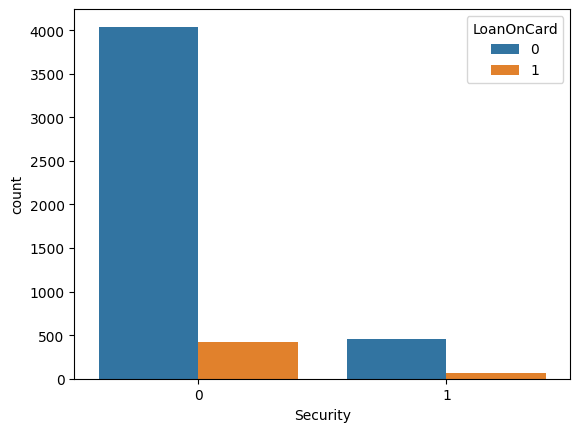

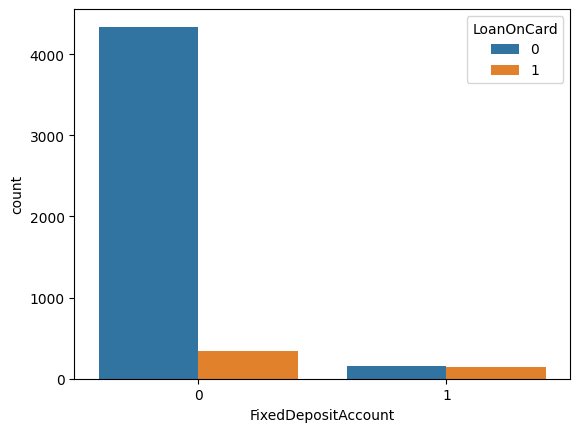

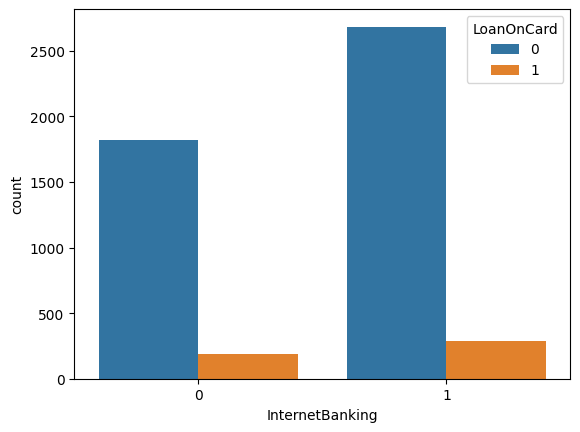

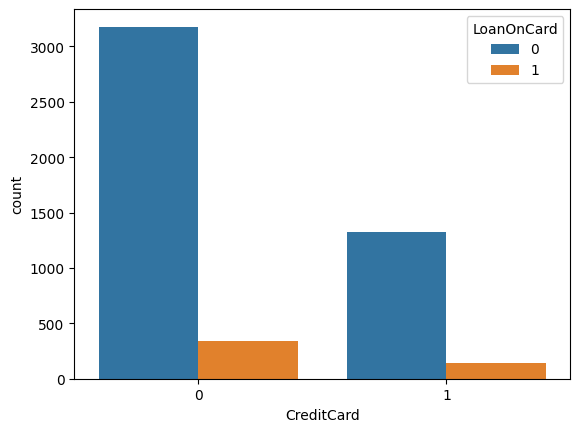

In [19]:
for col in binary_cols:

    sns.countplot(
        data=cust_data,
        x=col,
        hue=target_col
    )

    plt.show()

## Multivariate Analysis

## Numerical Feature Correlation

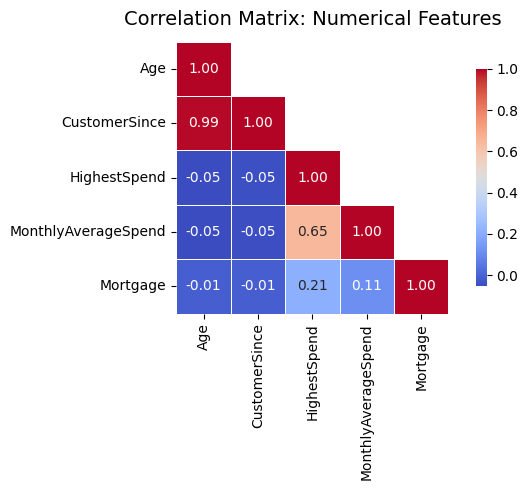

In [20]:
# Correlation Matrix for Numerical Features

# Check relationships among numerical predictors.

corr_matrix = cust_data[num_cols].corr()

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool),
    k=1
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Matrix: Numerical Features",
    fontsize=14,
    pad=12
)

plt.tight_layout()
plt.show()

## Observation

A correlation of 0.99 is almost a perfect linear relationship.

Age ≈ CustomerSince + Constant

which means these two variables contain nearly identical information.

Age and CustomerSince exhibit an extremely high positive correlation (r = 0.99), indicating severe multicollinearity.

### Business Interpretation

The relationship is expected because older customers generally tend to have longer relationships with the bank.

### Modeling Implication

To reduce multicollinearity and improve model interpretability:
- One of the two variables may be removed for linear models.
- Variance Inflation Factor (VIF) analysis will be conducted before making a final decision.
- Tree-based algorithms such as Decision Trees and Random Forests will also be evaluated using the complete feature set, as they are less sensitive to multicollinearity.

## Feature-Target Correlation

In [21]:
# Feature-Target Correlation

# Estimate linear association with target.

feature_target_cols = (
    num_cols
    + binary_cols
    + [target_col]
)

feature_target_corr = (
    cust_data[feature_target_cols]
    .corr()[target_col]
    .sort_values(ascending=False)
    .to_frame("Correlation with LoanOnCard")
)

feature_target_corr

,Correlation with LoanOnCard
LoanOnCard,1.00
HighestSpend,0.50
MonthlyAverageSpend,0.37
FixedDepositAccount,0.32
Mortgage,0.14
Security,0.02
InternetBanking,0.01
CreditCard,0.00
CustomerSince,-0.01
Age,-0.01


## Ordinal Association with Target

In [22]:
# Spearman Correlation for Ordinal Features and Target

ordinal_corr = (
    cust_data[ordinal_cols + [target_col]]
    .corr(method="spearman")[[target_col]]
    .sort_values(by=target_col, ascending=False)
    .reset_index()
)

ordinal_corr.columns = [
    "Feature",
    "Spearman Correlation"
]

ordinal_corr

,Feature,Spearman Correlation
0,LoanOnCard,1.00
1,Level,0.14
2,HiddenScore,0.06


## Correlation with Loan Ownership

### Strong Predictors

#### HighestSpend (r = 0.50)

HighestSpend exhibits the strongest positive correlation with loan ownership.

Customers with larger historical transaction amounts are substantially more likely to hold a credit card loan.

This finding aligns with earlier bivariate analysis, where loan holders demonstrated significantly higher spending behavior than non-loan customers.

#### MonthlyAverageSpend (r = 0.37)

MonthlyAverageSpend shows a moderate positive relationship with the target variable.

Customers who consistently spend more each month appear more likely to utilize credit products.

This suggests that ongoing spending behavior is an important indicator of borrowing propensity.

---

### Moderate Predictors
#### FixedDepositAccount (r = 0.32)

FixedDepositAccount demonstrates a moderate positive association with loan ownership.

Customers holding fixed deposit products may have stronger banking relationships and greater engagement with the institution's financial services.

This feature appears to carry meaningful predictive information.

---

### Weak Predictors
#### Mortgage (r = 0.14)

Mortgage exhibits a weak positive relationship with loan ownership.

Although borrowers generally maintain higher mortgage balances, the association is substantially weaker than spending-related features.

#### Level (ρ = 0.14)

Level shows a weak positive monotonic relationship with loan ownership.

Customers assigned to higher bank-defined levels appear slightly more likely to hold loan products.

While the relationship is modest, the feature may still contribute predictive value when combined with other variables.

---

### Very Weak Predictors
#### HiddenScore (ρ = 0.06)

HiddenScore exhibits only a very weak positive relationship with loan ownership.

When evaluated independently, the feature appears to provide limited predictive signal.

However, it will be retained for model training because weak individual relationships can still contribute value in multivariate models.

---

### Negligible Predictors

The following variables exhibit little to no linear relationship with loan ownership:
- Age
- CustomerSince
- Security
- InternetBanking
- CreditCard

These findings suggest that customer demographics and certain banking products may have limited standalone predictive power.

However, features showing low individual correlation should not be removed solely on this basis, as machine learning algorithms can often capture complex non-linear relationships and interactions that correlation analysis cannot detect.

## Multicollinearity Check

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = cust_data[
    num_cols +
    ordinal_cols +
    binary_cols
]

vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

def interpret_vif(vif_value):

    if vif_value < 2:
        return "Negligible Multicollinearity"

    elif vif_value < 5:
        return "Low Multicollinearity"

    elif vif_value < 10:
        return "Moderate Multicollinearity"

    else:
        return "High Multicollinearity"
vif["Interpretation"] = vif["VIF"].apply(interpret_vif)

vif = (
    vif
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif

,Feature,VIF,Interpretation
0,Age,75.84,High Multicollinearity
1,CustomerSince,29.47,High Multicollinearity
2,Level,6.59,Moderate Multicollinearity
3,HighestSpend,6.52,Moderate Multicollinearity
4,HiddenScore,5.51,Moderate Multicollinearity
5,MonthlyAverageSpend,3.85,Low Multicollinearity
6,InternetBanking,2.57,Low Multicollinearity
7,CreditCard,1.57,Negligible Multicollinearity
8,FixedDepositAccount,1.42,Negligible Multicollinearity
9,Mortgage,1.38,Negligible Multicollinearity


## Key Findings
### Severe Multicollinearity
#### Age (VIF = 75.84)
#### CustomerSince (VIF = 29.47)

Both variables exhibit extremely high VIF values, confirming the near-perfect correlation identified earlier (r = 0.99).

This indicates that both features provide highly overlapping information and contribute to severe multicollinearity.

### Business Interpretation

The relationship is expected because older customers generally have longer banking relationships.

### Modeling Implication

For linear models such as:

#### Logistic Regression
- one of these variables may eventually be removed to improve coefficient stability and interpretability.

However, the final decision will be made during Phase 4: Feature Engineering after evaluating feature importance and model performance.

---

### Moderate Multicollinearity
#### Level (VIF = 6.59)
#### HighestSpend (VIF = 6.52)
#### HiddenScore (VIF = 5.51)

These variables exhibit moderate multicollinearity.

However:
- Their VIF values remain below the commonly used threshold of 10.
- No immediate corrective action is required.
- They may still provide valuable predictive information.

#### Recommendation

Retain these variables for subsequent analysis and model development.

---

### Low Multicollinearity

The following variables exhibit acceptable VIF values:
#### MonthlyAverageSpend (VIF = 3.85)
#### InternetBanking (VIF = 2.57)

These values do not indicate problematic multicollinearity.

---

### No Multicollinearity Concerns

The remaining features show minimal correlation with other predictors:

- CreditCard
- FixedDepositAccount
- Mortgage
- Security

These variables are unlikely to cause instability in model estimation.

## Business Interpretation

### Suppose:

Age = 45
CustomerSince = 20

This implies:

Started banking around age 25

### Now another customer:

Age = 55
CustomerSince = 30

Again:

Started banking around age 25

The variables are basically measuring the same customer lifecycle information.

3.3.4 Statistical Testing
Numerical vs Target
Independent T-Test
ANOVA (if needed)
Categorical vs Target
Chi-Square Test

## Statistical Analysis

### Numerical vs Target

In [24]:
# Mann-Whitney U Test: Numerical Features vs LoanOnCard

from scipy.stats import mannwhitneyu
import pandas as pd

results = []

for col in num_cols:

    group_0 = cust_data.loc[cust_data["LoanOnCard"] == 0, col]
    group_1 = cust_data.loc[cust_data["LoanOnCard"] == 1, col]

    stat, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided"
    )

    results.append({
        "Variable": col,
        "Mean (No Loan)": round(group_0.mean(), 2),
        "Mean (Loan)": round(group_1.mean(), 2),
        "Median (No Loan)": round(group_0.median(), 2),
        "Median (Loan)": round(group_1.median(), 2),
        "P-Value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

results_df = pd.DataFrame(results)

results_df.sort_values("P-Value")

,Variable,Mean (No Loan),Mean (Loan),Median (No Loan),Median (Loan),P-Value,Significant
2,HighestSpend,66.29,144.75,59.00,142.50,0.00,Yes
3,MonthlyAverageSpend,1.73,3.91,1.40,3.80,0.00,Yes
4,Mortgage,51.87,100.85,0.00,0.00,0.00,Yes
0,Age,45.38,45.07,45.00,45.00,0.55,No
1,CustomerSince,20.15,19.84,20.00,20.00,0.56,No


## Interpretation
### HighestSpend
- Customers who accepted the loan have an average highest spend of 144.75, compared with 66.29 among non-adopters.
- The median highest spend is also substantially higher for loan adopters (142.5 vs 59.0).
- The extremely small p-value (p < 0.001) indicates that the observed difference is statistically significant.
- Both the mean and median differences suggest a strong and consistent relationship between spending capacity and loan adoption.

### Business Insight:

Customers with higher historical spending levels are significantly more likely to accept the loan offer, making HighestSpend one of the most influential predictors of loan adoption.

---

### MonthlyAverageSpend
- Loan adopters spend an average of 3.91 per month compared with 1.73 among non-adopters.
- The median monthly spend is also considerably higher (3.8 vs 1.4).
- The difference is highly statistically significant (p < 0.001).

### Business Insight:

Customers exhibiting higher ongoing spending activity are substantially more likely to adopt the loan product, indicating strong engagement with the bank's financial services.

---

### Mortgage
- Customers who accepted the loan have a higher average mortgage balance (100.85) than non-adopters (51.87).
- Although both groups have a median mortgage value of 0, the mean difference is statistically significant (p < 0.001).
- This suggests that a subset of customers with larger mortgage obligations contributes to the observed difference.

### Business Insight:

Existing financial commitments appear to increase the likelihood of loan adoption, possibly reflecting greater financing needs among these customers.

---

### Age
- The average and median ages are virtually identical across both groups.
- The p-value (0.546) indicates no statistically significant difference.

### Business Insight:

Age does not appear to meaningfully influence loan acceptance behavior in this customer population.

---

### CustomerSince
Average and median customer tenure values are nearly identical for both groups.
The p-value (0.555) indicates no statistically significant difference.

### Business Insight:

Length of relationship with the bank does not appear to be a key driver of loan adoption.

---

## Overall Conclusion

Statistical testing reveals that HighestSpend, MonthlyAverageSpend, and Mortgage are significantly associated with loan adoption, while Age and CustomerSince are not. The strongest differences are observed in spending-related variables, where loan adopters consistently exhibit substantially higher spending behavior than non-adopters. These findings suggest that customer financial activity is a more important determinant of loan acceptance than demographic characteristics or customer tenure.

### Ordinal vs Target

### Chi-Square Test

In [25]:
from scipy.stats import chi2_contingency

results = []

cat_features = binary_cols + ordinal_cols

for col in cat_features:

    table = pd.crosstab(
        cust_data[col],
        cust_data[target_col]
    )

    chi2, p, dof, expected = chi2_contingency(table)

    results.append({
        "Variable": col,
        "Chi-Square Statistic": round(chi2, 4),
        "Degrees of Freedom": dof,
        "P-Value": round(p, 6),
        "Significant (α=0.05)": "Yes" if p < 0.05 else "No"
    })

chi_square_results = (
    pd.DataFrame(results)
    .sort_values("P-Value")
    .reset_index(drop=True)
)

chi_square_results

,Variable,Chi-Square Statistic,Degrees of Freedom,P-Value,Significant (α=0.05)
0,FixedDepositAccount,493.22,1,0.00,Yes
1,Level,111.51,2,0.00,Yes
2,HiddenScore,29.81,3,0.00,Yes
3,Security,2.17,1,0.14,No
4,InternetBanking,0.14,1,0.71,No
5,CreditCard,0.02,1,0.90,No


## Observation
### FixedDepositAccount
- The Chi-Square statistic is 493.22, the largest among all categorical variables.
- The p-value is effectively 0.000, indicating a highly significant association with loan adoption.
- Customers with a fixed deposit account exhibit substantially different loan adoption behavior compared with customers without one.

### Business Insight:

FixedDepositAccount is the strongest categorical predictor of loan adoption and should be considered a highly informative feature during model development.

---

### Level
- The Chi-Square statistic of 111.51 indicates a strong relationship between customer level and loan adoption.
- The p-value is significantly below 0.05, confirming statistical significance.
- Loan adoption rates vary meaningfully across different customer levels.

### Business Insight:

Customer level appears to influence loan acceptance behavior and may reflect differences in income, status, or financial capacity.

---

### HiddenScore
- HiddenScore exhibits a statistically significant relationship with loan adoption (p < 0.001).
- Although its association is weaker than FixedDepositAccount and Level, the relationship remains meaningful.

### Business Insight:

HiddenScore provides useful predictive information and may capture customer characteristics associated with loan eligibility or financial strength.

---

### Security
- The p-value (0.141) exceeds the significance threshold of 0.05.
- No statistically significant association is observed between Security account ownership and loan adoption.

### Business Insight:

Security ownership does not appear to influence customers' likelihood of accepting the loan offer.

---

### InternetBanking
- The p-value (0.706) indicates no statistically significant relationship with loan adoption.
- Loan adoption behavior appears similar regardless of Internet Banking usage.

### Business Insight:

Internet banking adoption is not a meaningful differentiator between loan adopters and non-adopters.

---

### CreditCard
- The p-value (0.899) is substantially greater than 0.05.
- No evidence of association exists between credit card ownership and loan adoption.

### Business Insight:

Credit card ownership alone does not appear to impact loan acceptance behavior.

---

### Overall Conclusion
#### Significant Categorical Predictors
- FixedDepositAccount
- Level
- HiddenScore

#### Non-Significant Categorical Predictors
- Security
- InternetBanking
- CreditCard

### Summary

Chi-Square analysis identified FixedDepositAccount, Level, and HiddenScore as statistically significant categorical predictors of loan adoption. Among these variables, FixedDepositAccount exhibited the strongest association with the target variable. In contrast, Security, InternetBanking, and CreditCard showed no statistically significant relationship with loan acceptance. These findings suggest that customer financial profile characteristics are more influential in predicting loan adoption than ownership of auxiliary banking products.

# Phase 3: Exploratory Data Analysis (EDA) & Statistical Analysis Summary

## Overview

The objective of this phase was to explore the cleaned dataset, understand customer characteristics, identify patterns associated with loan ownership, evaluate relationships among variables, assess multicollinearity, and statistically validate observed trends.

The analysis included univariate, bivariate, and multivariate techniques, along with statistical hypothesis testing to identify features that may contribute to predicting customer loan adoption.

## Target Variable Analysis

The target variable (LoanOnCard) exhibited a substantial class imbalance.

LoanOnCard	Count	Percentage (%)
0	4,500	90.36
1	480	9.64

#### Key Findings
Only 9.64% of customers have a credit card loan.
The dataset represents a moderately imbalanced classification problem.
Accuracy alone would be an insufficient model evaluation metric.
Recall, Precision, F1-Score, ROC-AUC, and Confusion Matrix analysis will be emphasized during model evaluation.

### Univariate Analysis

#### Numerical Variables

Distribution analysis revealed:

| Feature | Distribution | Outliers |
|----------|-------------|----------|
| Age | Approximately Symmetric | No |
| CustomerSince | Approximately Symmetric | No |
| HighestSpend | Moderately Right-Skewed | Yes |
| MonthlyAverageSpend | Highly Right-Skewed | Yes |
| Mortgage | Extremely Right-Skewed | Yes |

#### Key Findings
- Spending-related variables exhibit strong positive skewness.
- Mortgage contains a large proportion of zero values and several high-value observations.
- Age and CustomerSince show stable distributions with no meaningful outliers.
- Outliers appear to reflect genuine customer behavior rather than data quality issues.

---

### Outlier Analysis

| Feature | Outlier Percentage (%) |
|----------|----------------------|
| MonthlyAverageSpend | 6.51 |
| Mortgage | 5.84 |
| HighestSpend | 1.93 |
| Age | 0.00 |
| CustomerSince | 0.00 |

#### Key Findings
- Most outliers occur in financial variables.
- No outliers were detected in Age or CustomerSince.
- Outliers were retained because they likely represent valid high-value customers.

---

#### Ordinal Variables

The dataset contains two ordinal features:
- Level
- HiddenScore

#### Key Findings
- Both variables exhibit valid category distributions.
- Higher category levels generally correspond to increased loan ownership rates.
- Level appears more informative than HiddenScore.

---

#### Binary Variables

The dataset contains four binary variables:
- Security
- FixedDepositAccount
- InternetBanking
- CreditCard

#### Key Findings
- FixedDepositAccount exhibits a notable relationship with loan ownership.
- Security, InternetBanking, and CreditCard show limited variation in loan conversion behavior.

---

### Bivariate Analysis

#### Numerical Features vs Loan Ownership

Comparison of borrowers and non-borrowers revealed significant differences in spending-related features.

| Variable | Mean (No Loan) | Mean (Loan) |
|----------|---------------:|------------:|
| HighestSpend | 66.29 | 144.75 |
| MonthlyAverageSpend | 1.73 | 3.91 |
| Mortgage | 51.87 | 100.85 |

#### Key Findings
- Loan holders demonstrate substantially higher spending behavior.
- Customers with loans maintain larger mortgage balances.
- Age and CustomerSince show minimal differences between groups.

---

#### Categorical Features vs Loan Ownership

Analysis of ordinal and binary variables revealed:

##### Significant Associations
- FixedDepositAccount
- Level
- HiddenScore

##### Non-Significant Associations
- Security
- InternetBanking
- CreditCard

---

### Multivariate Analysis

#### Correlation Analysis

Correlation analysis identified:

| Feature | Correlation with LoanOnCard |
|----------|----------------------------|
| HighestSpend | 0.50 |
| MonthlyAverageSpend | 0.37 |
| FixedDepositAccount | 0.32 |
| Mortgage | 0.14 |
| Level | 0.14 |

#### Key Findings
- HighestSpend exhibits the strongest positive correlation with loan ownership.
- Spending-related features consistently demonstrate the strongest predictive potential.
- Age and CustomerSince exhibit virtually no relationship with the target variable.

---

### Multicollinearity Assessment

Variance Inflation Factor (VIF) analysis identified one major multicollinearity concern.

| Feature | VIF |
|----------|------:|
| Age | 75.84 |
| CustomerSince | 29.47 |

#### Key Findings
- Age and CustomerSince exhibit severe multicollinearity.
- Both variables contain highly overlapping information.
- Feature retention decisions will be addressed during Feature Engineering.

---

### Statistical Testing

#### Mann-Whitney U Test (Numerical Features)

##### Statistically significant differences were observed for:
- HighestSpend
- MonthlyAverageSpend
- Mortgage

##### No significant differences were observed for:
- Age
- CustomerSince

---

#### Chi-Square Test (Categorical Features)

##### Statistically significant associations were identified for:
- FixedDepositAccount
- Level
- HiddenScore

##### No statistically significant associations were observed for:
- Security
- InternetBanking
- CreditCard

---

### Overall Business Insights

The analysis consistently indicates that loan ownership is driven primarily by customer financial behavior and banking engagement rather than demographic characteristics.

Customers who:
- Spend more frequently,
- Make larger transactions,
- Hold larger mortgage balances,
- Maintain fixed deposits,
- Belong to higher bank-defined customer segments,

are significantly more likely to possess a credit card loan.

Conversely, customer age, banking tenure, internet banking usage, and credit card ownership demonstrate limited influence on borrowing behavior.

---

### Conclusion

The exploratory analysis successfully identified the key factors associated with loan ownership. Spending behavior, mortgage balances, fixed deposit ownership, and customer segmentation variables emerged as the most informative predictors.

The findings also revealed class imbalance within the target variable and severe multicollinearity between Age and CustomerSince. These insights will guide feature engineering, feature selection, and model preparation in the next phase.

Based on the EDA findings, Phase 4 will focus on leakage prevention, target-feature separation, train-test splitting, multicollinearity handling, skewness treatment, ZipCode transformation, class imbalance strategy, and final feature matrix preparation for model training.

The dataset is now ready for feature engineering and model preparation.

# Phase 3 Deliverables Completed
- Target Variable Analysis
- Univariate Analysis
  - Numerical Features
  - Ordinal Features
  - Binary Features
- Outlier Analysis
- Bivariate Analysis
- Correlation Analysis
- Multicollinearity Analysis (VIF)
- Statistical Testing
  - Mann-Whitney U Test
  - Chi-Square Test
- Business Insights & Findings
- EDA & Statistical Analysis Summary